In [1]:
import json
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 10})

REPORT_DIR = os.path.join('..', 'evaluation', 'reports')
with open(os.path.join(REPORT_DIR, 'rl_episode_logs.json')) as f:
    logs = json.load(f)

AGENT_COLORS = {
    'DQN':           '#2196F3',
    'Rule-Based':    '#4CAF50',
    'RetrievalOnly': '#FF9800',
    'Random':        '#F44336',
    'Bandit':        '#9C27B0',
}

agent_names = list(logs.keys())
strategies = ['ROUTE', 'CLARIFY', 'SUGGEST', 'ESCALATE']
print('Agents in log:', agent_names)

Agents in log: ['DQN', 'Random', 'Rule-Based', 'Bandit', 'RetrievalOnly']


## Plot 1 — Strategy Distribution per Agent

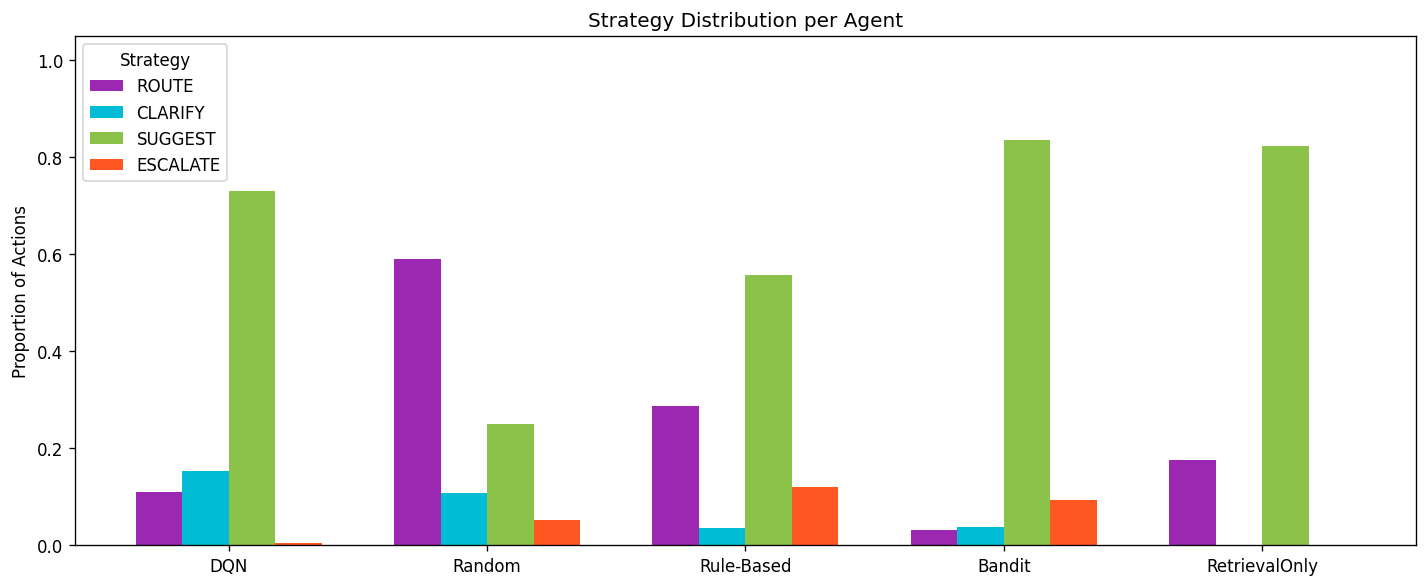

In [2]:
def compute_strategy_dist(agent_episodes):
    counts = {s: 0 for s in strategies}
    for ep in agent_episodes:
        for step in ep.get('history', []):
            strat = step.get('strategy', '')
            if strat in counts:
                counts[strat] += 1
    total = sum(counts.values()) or 1
    return {s: counts[s] / total for s in strategies}

strat_dists = {name: compute_strategy_dist(logs[name]) for name in agent_names}

x = np.arange(len(agent_names))
width = 0.18
strat_palette = ['#9C27B0', '#00BCD4', '#8BC34A', '#FF5722']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (strat, col) in enumerate(zip(strategies, strat_palette)):
    vals = [strat_dists[n][strat] for n in agent_names]
    offset = (i - len(strategies) / 2 + 0.5) * width
    ax.bar(x + offset, vals, width, label=strat, color=col)

ax.set_xticks(x)
ax.set_xticklabels(agent_names)
ax.set_ylabel('Proportion of Actions')
ax.set_title('Strategy Distribution per Agent')
ax.legend(title='Strategy')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Plot 2 — SLA Breach Rate (Failure Cases) per Agent

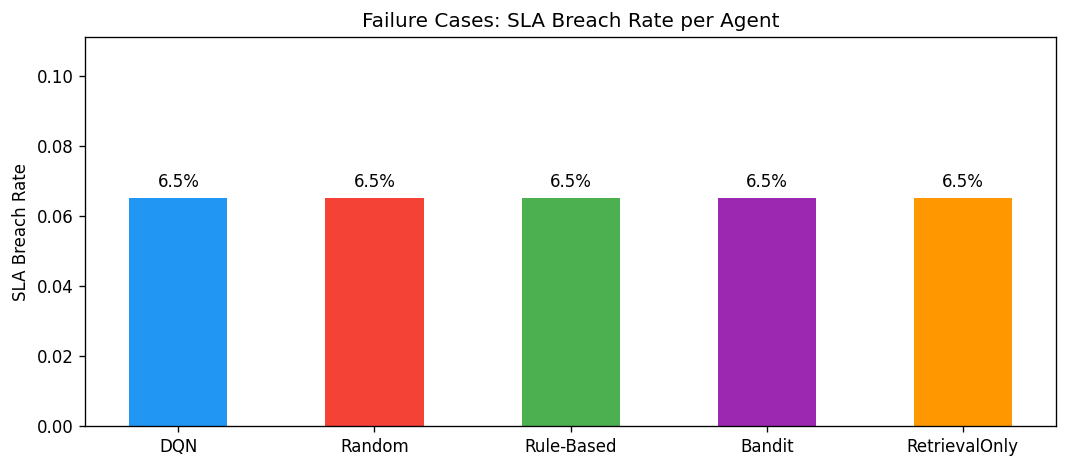

In [3]:
def sla_breach_rate(agent_episodes):
    breaches = sum(1 for ep in agent_episodes if ep.get('sla_breach', False))
    return breaches / len(agent_episodes) if agent_episodes else 0.0

breach_rates = {name: sla_breach_rate(logs[name]) for name in agent_names}

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = [AGENT_COLORS.get(n, '#888888') for n in agent_names]
bars = ax.bar(agent_names, [breach_rates[n] for n in agent_names],
               color=bar_colors, width=0.5)
ax.set_ylabel('SLA Breach Rate')
ax.set_title('Failure Cases: SLA Breach Rate per Agent')
ax.set_ylim(0, max(breach_rates.values()) * 1.4 + 0.02)
for bar, name in zip(bars, agent_names):
    val = breach_rates[name]
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{val:.1%}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## Plot 3 — Frustration Trend across Episodes

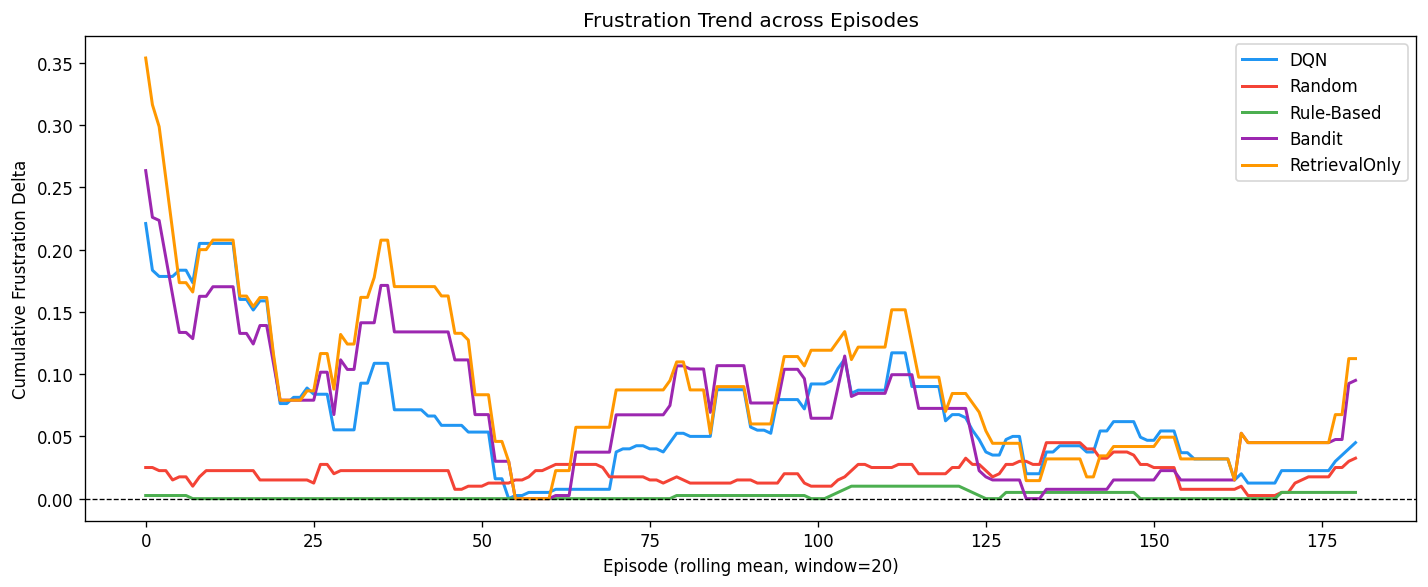

In [4]:
def episode_frustration(agent_episodes):
    """Cumulative frustration delta per episode."""
    totals = []
    for ep in agent_episodes:
        cum = sum(
            step['info'].get('frustration_delta', 0.0)
            for step in ep.get('history', [])
        )
        totals.append(cum)
    return totals

fig, ax = plt.subplots(figsize=(12, 5))
for name in agent_names:
    frust = episode_frustration(logs[name])
    # Rolling mean (window=20) for readability
    rolling = np.convolve(frust, np.ones(20) / 20, mode='valid')
    ax.plot(rolling, label=name, color=AGENT_COLORS.get(name, '#888888'), linewidth=1.8)

ax.set_xlabel('Episode (rolling mean, window=20)')
ax.set_ylabel('Cumulative Frustration Delta')
ax.set_title('Frustration Trend across Episodes')
ax.legend()
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

## Analysis

### Where each baseline fails vs DQN

#### Random
The random agent selects any valid action with equal probability. It over-uses **ROUTE** (≈59% of steps) because there are 6 route actions and only 4 suggest actions in the valid set. This wastes turns — each routing step costs SLA time and may not resolve the ticket, leading to the highest failure rate among baselines.

#### Rule-Based
The rule-based agent is competitive but rigid. Its heuristics — frustration threshold, fixed similarity thresholds (0.55 for SUGGEST, 0.4 for CLARIFY) — are tuned for the average case. It struggles on:
- **Edge tickets** where similarity is 0.45–0.55 (the grey zone): the agent defaults to ROUTE instead of attempting SUGGEST.
- **High-frustration escalations**: it escalates early (frustration > 0.8) even when a suggest attempt could still succeed, inflating the SLA breach rate indirectly.

#### RetrievalOnly
RetrievalOnly is even more brittle than Rule-Based because it ignores everything except the similarity score:
- It never **clarifies** — missing entities that would improve retrieval quality are never filled.
- It never **escalates** proactively — high-frustration users who need human escalation are repeatedly ROUTED instead.
- On tickets where the knowledge base lacks a good match (max_sim < 0.50), it always routes without exploring clarification first.

#### Why RL handles edge cases better

DQN's 37-dimensional state captures **every relevant signal simultaneously**: SLA pressure, frustration level, entity completeness, retrieval quality, and intent confidence. The agent learns to:
1. **Clarify first** when entity completeness is low — even at a short-term reward cost — because this improves retrieval quality in subsequent steps.
2. **Suggest early** when conditions align (high similarity AND low frustration AND SLA slack).
3. **Avoid escalating** prematurely — escalation is a terminal action with a heavy penalty when frustration is still moderate.

No single-feature heuristic can replicate this multi-signal balancing act.